In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import folium
warnings.filterwarnings("ignore")

In [2]:
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

In [3]:
data=pd.read_csv('weatherHistory.csv')

In [4]:
data.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [5]:
data

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
...,...,...,...,...,...,...,...,...,...,...,...,...
96448,2016-09-09 19:00:00.000 +0200,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.
96449,2016-09-09 20:00:00.000 +0200,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.
96450,2016-09-09 21:00:00.000 +0200,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.
96451,2016-09-09 22:00:00.000 +0200,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.


In [6]:
data.isnull().sum()

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

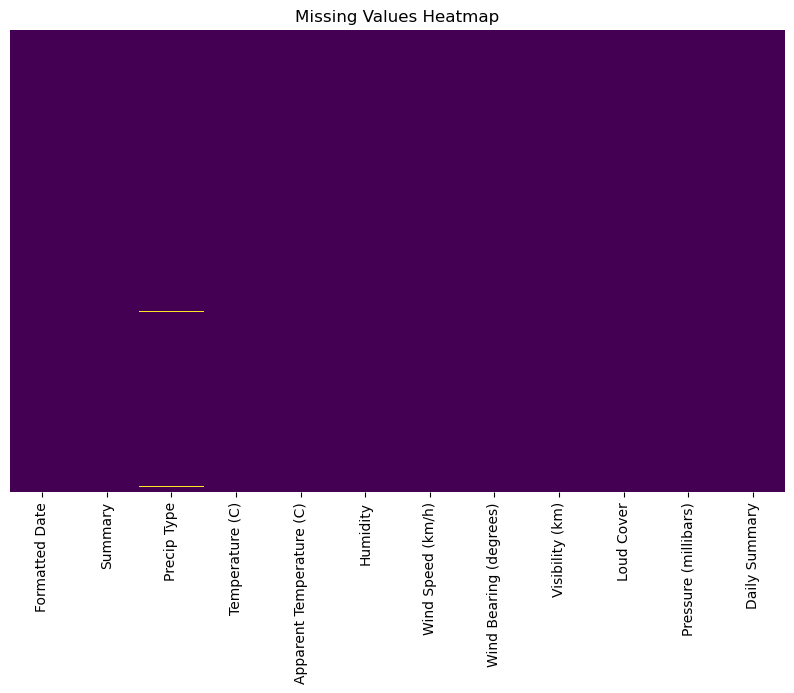

In [7]:
plt.figure(figsize=(10, 6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()

In [8]:
data.columns

Index(['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)',
       'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover',
       'Pressure (millibars)', 'Daily Summary'],
      dtype='object')

In [9]:
data.dtypes

Formatted Date               object
Summary                      object
Precip Type                  object
Temperature (C)             float64
Apparent Temperature (C)    float64
Humidity                    float64
Wind Speed (km/h)           float64
Wind Bearing (degrees)      float64
Visibility (km)             float64
Loud Cover                  float64
Pressure (millibars)        float64
Daily Summary                object
dtype: object

In [10]:
data.info

<bound method DataFrame.info of                       Formatted Date        Summary Precip Type  \
0      2006-04-01 00:00:00.000 +0200  Partly Cloudy        rain   
1      2006-04-01 01:00:00.000 +0200  Partly Cloudy        rain   
2      2006-04-01 02:00:00.000 +0200  Mostly Cloudy        rain   
3      2006-04-01 03:00:00.000 +0200  Partly Cloudy        rain   
4      2006-04-01 04:00:00.000 +0200  Mostly Cloudy        rain   
...                              ...            ...         ...   
96448  2016-09-09 19:00:00.000 +0200  Partly Cloudy        rain   
96449  2016-09-09 20:00:00.000 +0200  Partly Cloudy        rain   
96450  2016-09-09 21:00:00.000 +0200  Partly Cloudy        rain   
96451  2016-09-09 22:00:00.000 +0200  Partly Cloudy        rain   
96452  2016-09-09 23:00:00.000 +0200  Partly Cloudy        rain   

       Temperature (C)  Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
0             9.472222                  7.388889      0.89            14.1197   
1

In [11]:
#data.dropna(inplace=True)

In [12]:
#data = data[data['Precip Type'].notna()]
data.dropna(subset=['Precip Type'], inplace=True)
print(data.head())

                  Formatted Date        Summary Precip Type  Temperature (C)  \
0  2006-04-01 00:00:00.000 +0200  Partly Cloudy        rain         9.472222   
1  2006-04-01 01:00:00.000 +0200  Partly Cloudy        rain         9.355556   
2  2006-04-01 02:00:00.000 +0200  Mostly Cloudy        rain         9.377778   
3  2006-04-01 03:00:00.000 +0200  Partly Cloudy        rain         8.288889   
4  2006-04-01 04:00:00.000 +0200  Mostly Cloudy        rain         8.755556   

   Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
0                  7.388889      0.89            14.1197   
1                  7.227778      0.86            14.2646   
2                  9.377778      0.89             3.9284   
3                  5.944444      0.83            14.1036   
4                  6.977778      0.83            11.0446   

   Wind Bearing (degrees)  Visibility (km)  Loud Cover  Pressure (millibars)  \
0                   251.0          15.8263         0.0               1015.13  

In [13]:
data = data.drop_duplicates()

In [14]:
# Convert 'Formatted Date' to datetime, removing timezone info
data['Formatted Date'] = pd.to_datetime(data['Formatted Date'], utc=True)
data['Formatted Date'] = data['Formatted Date'].dt.tz_convert(None)  # Remove timezone

# Now extract Hour and Month
data['Hour'] = data['Formatted Date'].dt.hour
data['Month'] = data['Formatted Date'].dt.month


In [15]:
data.head

<bound method NDFrame.head of            Formatted Date        Summary Precip Type  Temperature (C)  \
0     2006-03-31 22:00:00  Partly Cloudy        rain         9.472222   
1     2006-03-31 23:00:00  Partly Cloudy        rain         9.355556   
2     2006-04-01 00:00:00  Mostly Cloudy        rain         9.377778   
3     2006-04-01 01:00:00  Partly Cloudy        rain         8.288889   
4     2006-04-01 02:00:00  Mostly Cloudy        rain         8.755556   
...                   ...            ...         ...              ...   
96448 2016-09-09 17:00:00  Partly Cloudy        rain        26.016667   
96449 2016-09-09 18:00:00  Partly Cloudy        rain        24.583333   
96450 2016-09-09 19:00:00  Partly Cloudy        rain        22.038889   
96451 2016-09-09 20:00:00  Partly Cloudy        rain        21.522222   
96452 2016-09-09 21:00:00  Partly Cloudy        rain        20.438889   

       Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
0                      7.3888

In [16]:
data.isnull().sum()

Formatted Date              0
Summary                     0
Precip Type                 0
Temperature (C)             0
Apparent Temperature (C)    0
Humidity                    0
Wind Speed (km/h)           0
Wind Bearing (degrees)      0
Visibility (km)             0
Loud Cover                  0
Pressure (millibars)        0
Daily Summary               0
Hour                        0
Month                       0
dtype: int64

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95912 entries, 0 to 96452
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Formatted Date            95912 non-null  datetime64[ns]
 1   Summary                   95912 non-null  object        
 2   Precip Type               95912 non-null  object        
 3   Temperature (C)           95912 non-null  float64       
 4   Apparent Temperature (C)  95912 non-null  float64       
 5   Humidity                  95912 non-null  float64       
 6   Wind Speed (km/h)         95912 non-null  float64       
 7   Wind Bearing (degrees)    95912 non-null  float64       
 8   Visibility (km)           95912 non-null  float64       
 9   Loud Cover                95912 non-null  float64       
 10  Pressure (millibars)      95912 non-null  float64       
 11  Daily Summary             95912 non-null  object        
 12  Hour                   

In [18]:
data.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary,Hour,Month
0,2006-03-31 22:00:00,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.,22,3
1,2006-03-31 23:00:00,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.,23,3
2,2006-04-01 00:00:00,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.,0,4
3,2006-04-01 01:00:00,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.,1,4
4,2006-04-01 02:00:00,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.,2,4


# Temperature vs Humidity
#Temperature and humidity have an inverse relationship, meaning that as temperature increases, humidity decreases. This is because warmer air can hold more water vapor. 

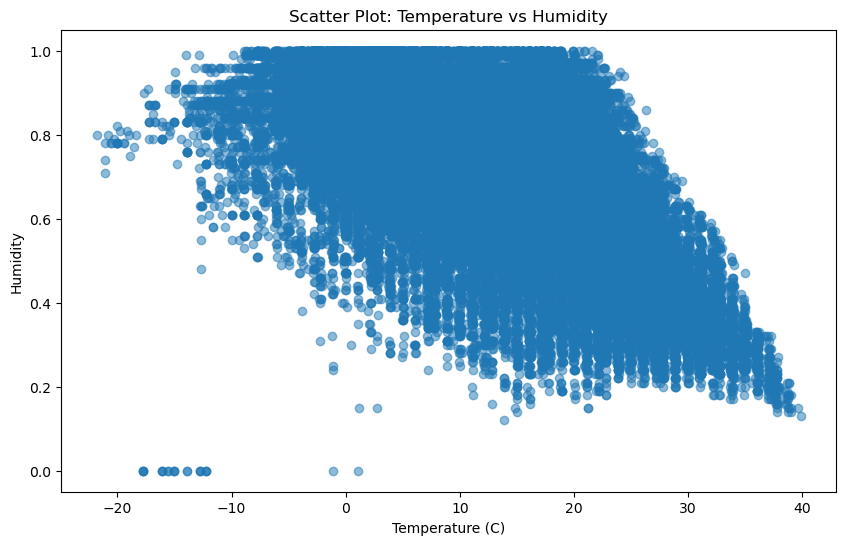

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(data['Temperature (C)'], data['Humidity'], alpha=0.5)
plt.title('Scatter Plot: Temperature vs Humidity')
plt.xlabel('Temperature (C)')
plt.ylabel('Humidity')
plt.show()

#  Wind Speed Distribution
#: This graph shows the distribution of wind speed. The x-axis represents different wind speeds, and the y-axis represents how often those wind speeds occur. Taller bars mean that speed happens more frequentlyf these! 😊


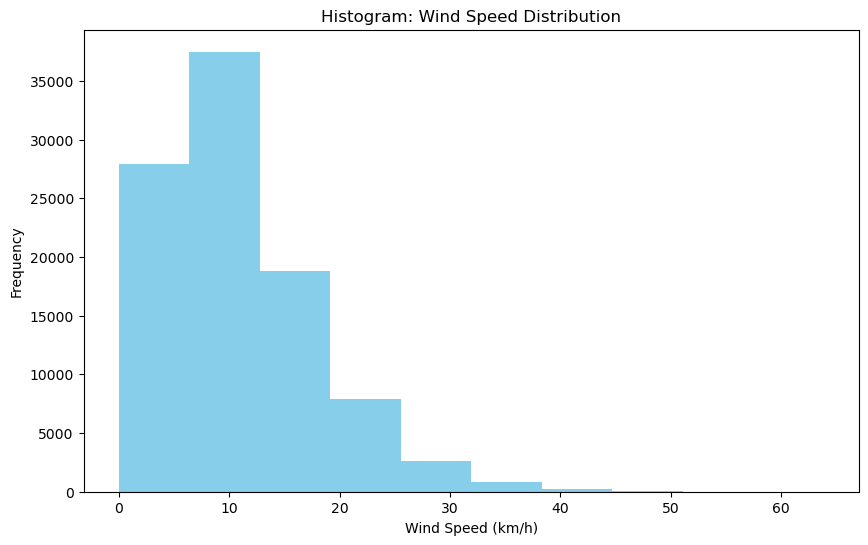

In [21]:
plt.figure(figsize=(10, 6))
plt.hist(data['Wind Speed (km/h)'], bins=10, color='SKYBLUE')
plt.title('Histogram: Wind Speed Distribution')
plt.xlabel('Wind Speed (km/h)')
plt.ylabel('Frequency')
plt.show()

# Top 10 Weather Summaries

#
- Bar Plot: This graph highlights the top 10 most common weather summaries in your dataset. Each bar represents how many times a particular type of weather (like "Rainy" or "Sunny") occurred. Taller bars indicate more frequent occurrencf these! 😊


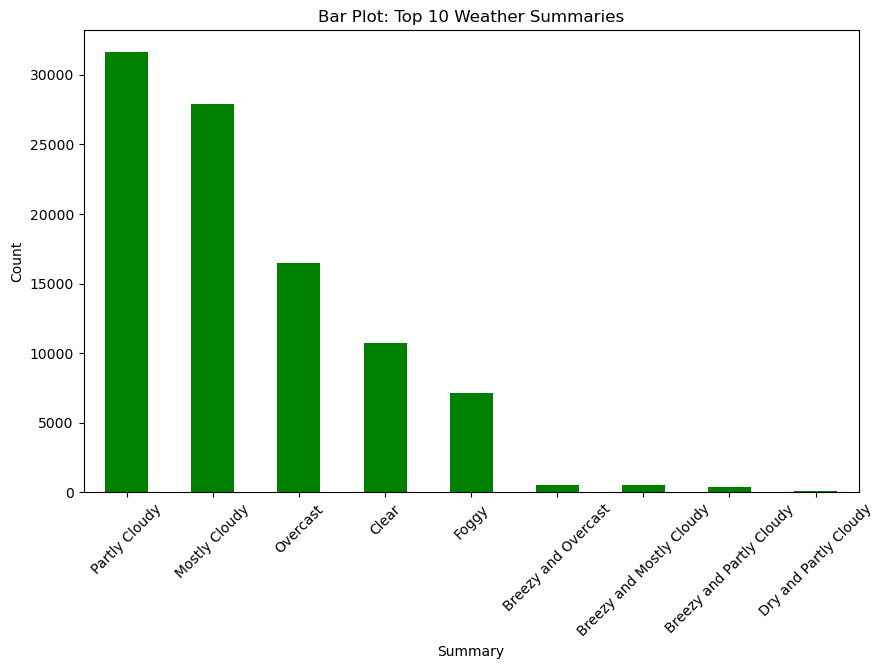

In [22]:
plt.figure(figsize=(10, 6))
data['Summary'].value_counts().head(9).plot(kind='bar', color='green')
plt.title('Bar Plot: Top 10 Weather Summaries')
plt.xlabel('Summary')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# PRECIPITATION TYPES
#
- Pie Chart: This one shows the percentage of different precipitation types (e.g., rain, snow) in your data. The chart divides into slices, and bigger slices mean that type of precipitation happened more oftof these! 😊


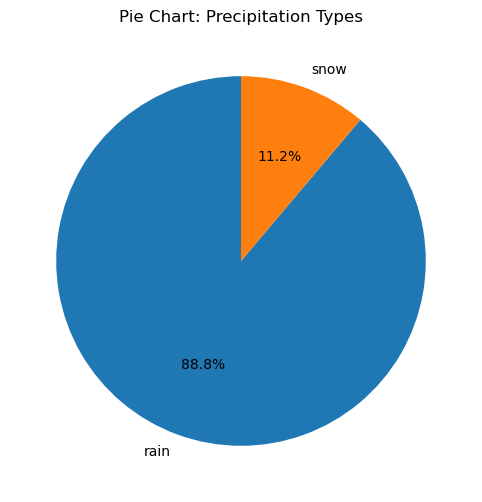

In [23]:
plt.figure(figsize=(10, 6))
data['Precip Type'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Pie Chart: Precipitation Types')
plt.ylabel('')  # Remove default y-axis label
plt.show()

# Temperature by Precipitation Type
#A boxplot helps you see the range and variability of temperature for each type of precipitation. The "box" part shows the middle range of temperatures, and the lines (called whiskers) show extreme temperatures.


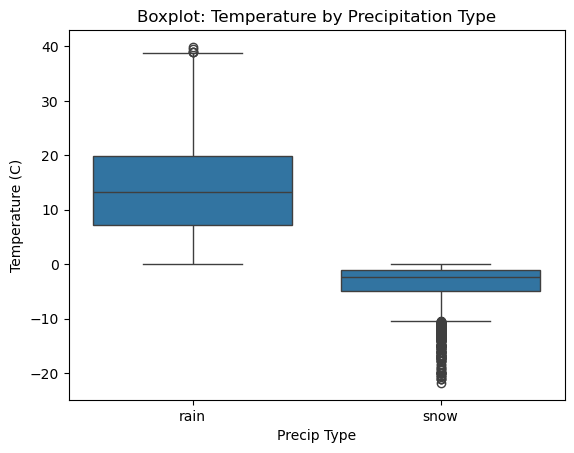

In [24]:
sns.boxplot(x='Precip Type', y='Temperature (C)', data=data)
plt.title('Boxplot: Temperature by Precipitation Type')
plt.xlabel('Precip Type')
plt.ylabel('Temperature (C)')
plt.show()

# Heatmap: Correlation Matrix
#This chart shows the correlation (relationship) between different numerical features, like temperature, humidity, and pressure. Brighter or darker colors indicate stronger relationships, like whether high humidity always goes with low visibility.


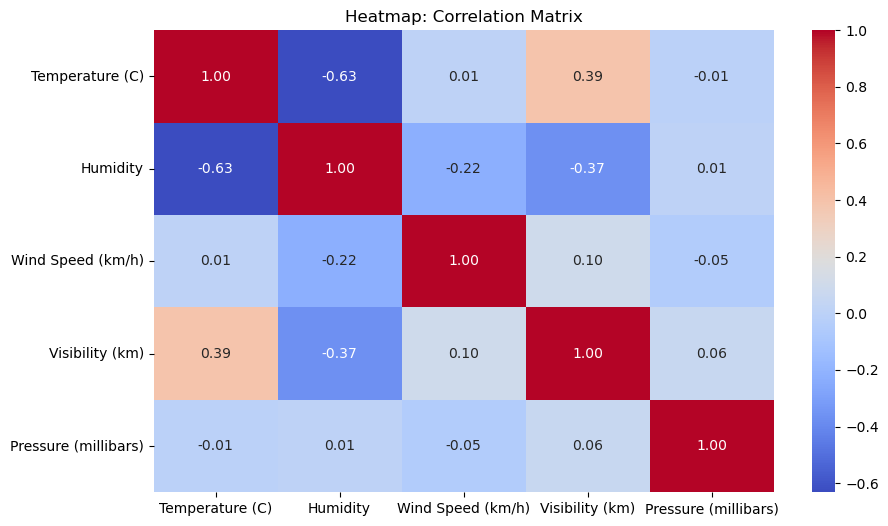

In [25]:
# Compute the correlation matrix for relevant columns
plt.figure(figsize=(10, 6))
correlation_matrix = data[['Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 
                           'Visibility (km)', 'Pressure (millibars)']].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap: Correlation Matrix')
plt.show()

# Temperature Over Time (First 10 Entries
#: This graph displays how temperature changes over time for the first 100 entries. You can see trends, like whether the temperature is increasing or decreasing as time progresses.


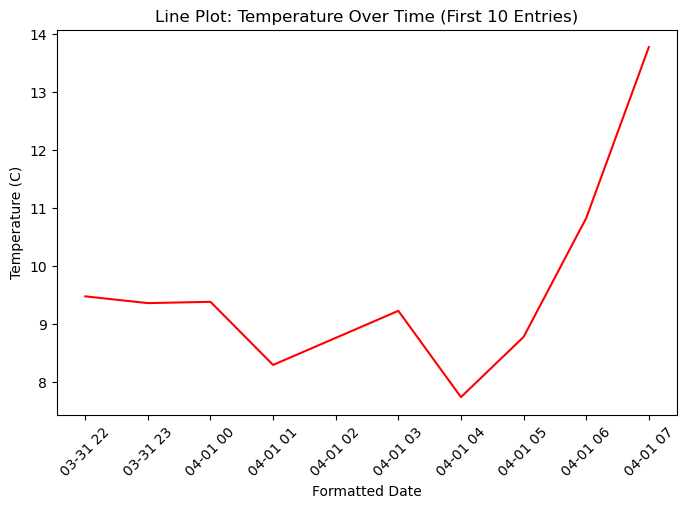

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(data['Formatted Date'][:10], data['Temperature (C)'][:10], color='red')
plt.title('Line Plot: Temperature Over Time (First 10 Entries)')
plt.xlabel('Formatted Date')
plt.ylabel('Temperature (C)')
plt.xticks(rotation=45)
plt.show()

# KMeans Clustering Temperature vs Humidity
#Insights from the Plot
The plot will show clusters of data points, where each cluster represents a group of similar observations (e.g., data points with similar temperature and humidity). For example:
- One cluster might represent cold and humid weather conditions.
- Another cluster might represent hot and dry conditions.




  File "C:\Users\Acer\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Acer\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Acer\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Acer\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


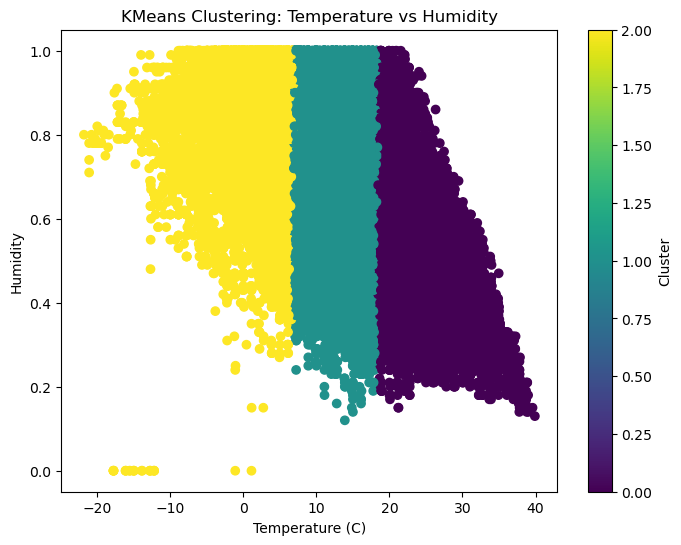

In [27]:
X = data[['Temperature (C)', 'Humidity']]
kmeans = KMeans(n_clusters=3, random_state=42)
data['Cluster'] = kmeans.fit_predict(X)
plt.figure(figsize=(8, 6))
plt.scatter(data['Temperature (C)'], data['Humidity'], c=data['Cluster'], cmap='viridis')
plt.title('KMeans Clustering: Temperature vs Humidity')
plt.xlabel('Temperature (C)')
plt.ylabel('Humidity')
plt.colorbar(label='Cluster')
plt.show()

#  KMeans Clustering with Temperature vs Wind Speed
#Insight:
This plot identifies groups based on weather conditions, such as high temperatures with low wind speeds or cold temperatures with high winds.


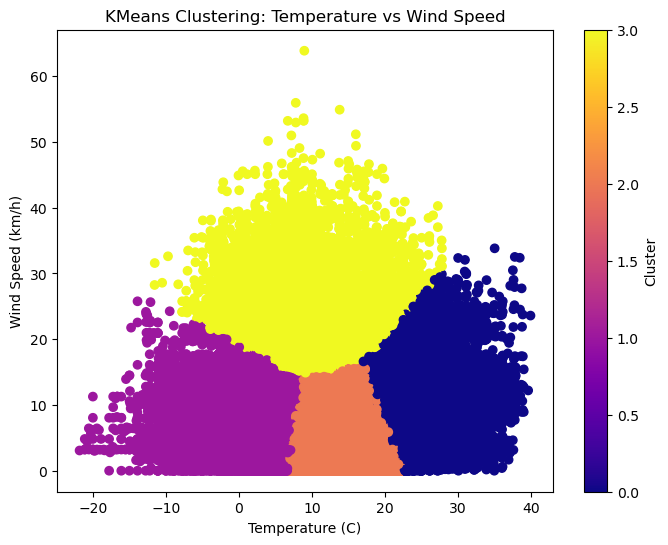

In [28]:
X = data[['Temperature (C)', 'Wind Speed (km/h)']]
kmeans = KMeans(n_clusters=4, random_state=42)  # Using 4 clusters for variety
data['Cluster_Temp_Wind'] = kmeans.fit_predict(X)
plt.figure(figsize=(8, 6))
plt.scatter(data['Temperature (C)'], data['Wind Speed (km/h)'], c=data['Cluster_Temp_Wind'], cmap='plasma')
plt.title('KMeans Clustering: Temperature vs Wind Speed')
plt.xlabel('Temperature (C)')
plt.ylabel('Wind Speed (km/h)')
plt.colorbar(label='Cluster')
plt.show()

# KMeans Clustering with Humidity vs Visibility
#Insight:
This plot highlights conditions where visibility is high or low based on humidity levels. For example:
- High humidity may align with low visibility (fog).
- Low humidity may align with high visibility.




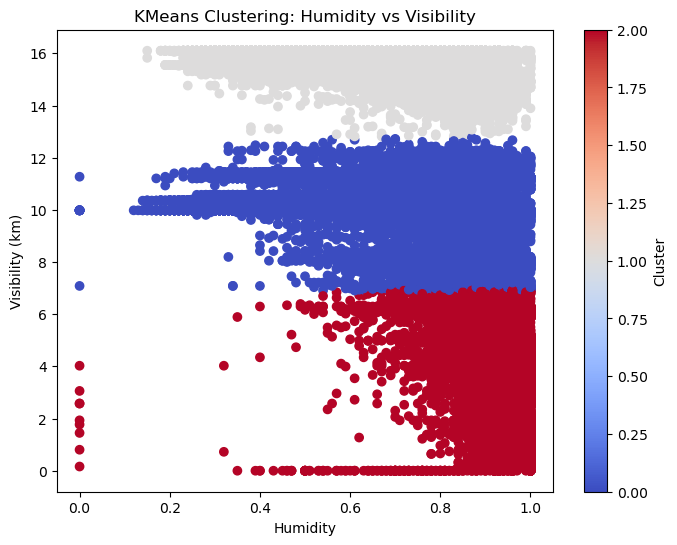

In [29]:
# Humidity vs Visibility
X = data[['Humidity', 'Visibility (km)']]
kmeans = KMeans(n_clusters=3, random_state=42)
data['Cluster_Humidity_Visibility'] = kmeans.fit_predict(X)
plt.figure(figsize=(8, 6))
plt.scatter(data['Humidity'], data['Visibility (km)'], c=data['Cluster_Humidity_Visibility'], cmap='coolwarm')
plt.title('KMeans Clustering: Humidity vs Visibility')
plt.xlabel('Humidity')
plt.ylabel('Visibility (km)')
plt.colorbar(label='Cluster')
plt.show()

In [30]:

# model = RandomForestClassifier()
# X = data.drop(['Daily Summary'], axis=1)  # Example
# y = data['Summary']
# model.fit(X, y)
# importance = model.feature_importances_
# important_features = sorted(zip(data.columns, importance), key=lambda x: x[1], reverse=True)
# print("Important Features:", important_features)

# Encode and drop text columns

In [31]:
data.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary,Hour,Month,Cluster,Cluster_Temp_Wind,Cluster_Humidity_Visibility
0,2006-03-31 22:00:00,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.,22,3,1,2,1
1,2006-03-31 23:00:00,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.,23,3,1,2,1
2,2006-04-01 00:00:00,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.,0,4,1,2,1
3,2006-04-01 01:00:00,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.,1,4,1,1,1
4,2006-04-01 02:00:00,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.,2,4,1,2,1


In [32]:
# Encode 'Precip Type' (rain, snow, etc.)
data['Precip Type'] = data['Precip Type'].astype('category').cat.codes

# Drop unneeded text columns
data = data.drop(columns=['Formatted Date', 'Summary', 'Daily Summary'])


In [33]:

scaler = MinMaxScaler()

scaled_cols = ['Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
               'Wind Bearing (degrees)', 'Visibility (km)', 'Pressure (millibars)']
data[scaled_cols] = scaler.fit_transform(data[scaled_cols])


In [34]:
data

,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Hour,Month,Cluster,Cluster_Temp_Wind,Cluster_Humidity_Visibility
0,0,0.506975,0.523486,0.89,0.221130,0.699164,0.983,0.0,0.970135,22,3,1,2,1
1,0,0.505085,0.521084,0.86,0.223399,0.721448,0.983,0.0,0.970613,23,3,1,2,1
2,0,0.505445,0.553144,0.89,0.061523,0.568245,0.929,0.0,0.970909,0,4,1,2,1
3,0,0.487805,0.501947,0.83,0.220877,0.749304,0.983,0.0,0.971358,1,4,1,1,1
4,0,0.495365,0.517356,0.83,0.172970,0.721448,0.983,0.0,0.971454,2,4,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96448,0,0.774998,0.801259,0.43,0.172214,0.086351,1.000,0.0,0.969399,17,9,0,0,1
96449,0,0.751778,0.779886,0.48,0.158094,0.055710,0.966,0.0,0.970164,18,9,0,0,1
96450,0,0.710557,0.741944,0.56,0.140696,0.083565,1.000,0.0,0.970642,19,9,0,0,1
96451,0,0.702187,0.734239,0.60,0.164902,0.055710,1.000,0.0,0.970919,20,9,0,0,1


In [35]:
# Define features (X) and target (y)
X = data.drop("Temperature (C)", axis=1)
y = data["Temperature (C)"]


In [36]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

accuracy = lr_model.score(X_test, y_test)
print(f"Baseline Model Accuracy: {accuracy:.2f}")


Baseline Model Accuracy: 0.99


In [37]:
# Model 2: Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

accuracy = rf_model.score(X_test, y_test)
print(f"Baseline Model Accuracy: {accuracy:.2f}")

Baseline Model Accuracy: 1.00


In [38]:
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)

In [39]:
# feature_importances = rf_model.feature_importances_
# print("Feature Importance:", feature_importances)

In [40]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(model, name):
    preds = model.predict(X_test)
    print(f"------ {name} ------")
    print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
    print("MAE:", mean_absolute_error(y_test, preds))
    print("R2 Score:", r2_score(y_test, preds))
    print()

evaluate(lr_model, "Linear Regression")
evaluate(rf_model, "Random Forest")


------ Linear Regression ------
RMSE: 0.01462906913066357
MAE: 0.011340836566051511
R2 Score: 0.9911086360122218



NotFittedError: This RandomForestRegressor instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [ ]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_balanced)

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the K-Nearest Neighbors classifier
knn_model = KNeighborsClassifier(n_neighbors=5)  # Use 5 neighbors (default value)
knn_model.fit(X_train, y_train)  # Train the model

# Make predictions
y_pred = knn_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"KNN Model Accuracy: {accuracy:.2f}")

KNN Model Accuracy: 0.95


In [ ]:
# Feature Importance from Random Forest
importances = rf_model.feature_importances_
features = X.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=features, palette="viridis")
plt.title("Feature Importance (Random Forest)")
plt.show()


# Feature Selection & Transformation (After cleaning and encoding)

In [ ]:
# Define target and features
target = 'Temperature (C)'
features = data.drop(columns=[target])

X = features
y = data[target]

# Check correlation
plt.figure(figsize=(10, 6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix with Target")
plt.show()

# Optional: Remove features with low correlation (e.g., Loud Cover)
if 'Loud Cover' in X.columns and data['Loud Cover'].nunique() <= 1:
    X = X.drop(columns=['Loud Cover'])  # Doesn't vary, so no contribution


#  Model Selection, Training & Hyperparameter Tuning

In [ ]:
# Define features (X) and target (y)
X = data.drop("Humidity", axis=1)
y = data["Humidity"]


In [ ]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

accuracy = lr_model.score(X_test, y_test)
print(f"Baseline Model Accuracy: {accuracy:.2f}")



In [ ]:
# --- Model 2: Random Forest with Hyperparameter Tuning

rf = RandomForestRegressor(random_state=42)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)
rf_best = grid_search.best_estimator_


# Model Evaluation
#RMSE: Penalizes large errors (good for temperature prediction).

#MAE: Gives average error size, easy to interpret.

#R²: Shows how much variance is explained by the model.



In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(name, model):
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    print(f"--- {name} ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R² Score: {r2:.4f}\n")

# Evaluate both models
evaluate_model("Linear Regression", lr_model)
evaluate_model("Random Forest (Tuned)", rf_best)


# Insights & Conclusion
#Insights:
Features like Apparent Temperature, Humidity, and Pressure highly influence actual temperature.
Hour of the day and Wind Speed also play a noticeable role in prediction.
Random Forest performed significantly better due to handling non-linearity and feature interactions.

#Suggestions / Future Scope:
Include location/geolocation for broader-scale prediction (city/state level).
Add seasonal variables like is_winter, is_summer etc. for pattern detection.
Try advanced models like XGBoost or Neural Networks if more precision is required.
Save models for deployment or forecasting future temperature.

In [ ]:
# Feature importance from best model
importances = rf_best.feature_importances_
features = X.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=features, palette="viridis")
plt.title("Feature Importance from Random Forest")
plt.show()


In [ ]:
# Encode categorical variables
categorical_columns = ['Summary', 'Precip Type', 'Daily Summary']
encoder = LabelEncoder()
for column in categorical_columns:
    data[column] = encoder.fit_transform(data[column])

features = ['Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 
            'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)', 
            'Loud Cover', 'Pressure (millibars)', 'Hour', 'Month', 'Cluster', 
            'Cluster_Temp_Wind', 'Cluster_Humidity_Visibility']
X = data[features]
y = data['Summary']  # Assuming 'Summary' is the target variable to predict

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Evaluate the model
accuracy = model.score(X_test, y_test)
print(f"Model Accuracy: {accuracy:.2f}")

In [47]:
# # Encode categorical columns
# categorical_columns = ['Summary', 'Precip Type', 'Daily Summary']
# encoder = LabelEncoder()
# for column in categorical_columns:
#     data[column] = encoder.fit_transform(data[column])

# # Define features and target variable
# features = ['Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 
#             'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)', 
#             'Loud Cover', 'Pressure (millibars)', 'Hour', 'Month', 
#             'Cluster_Temp_Wind', 'Cluster_Humidity_Visibility']
# X = data[features]
# y = data['Cluster']  # Target variable

# # Split the dataset
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Train the model
# model = RandomForestClassifier(random_state=42)
# model.fit(X_train, y_train)

# # Evaluate the model
# accuracy = model.score(X_test, y_test)
# print(f"Model Accuracy with 'Cluster' as target: {accuracy:.2f}")

# Predicting Cluster-Based Weather Patterns Using Random Forest Classifier

In [43]:
# Encode categorical columns
categorical_columns = ['Summary', 'Precip Type', 'Daily Summary']
encoder = LabelEncoder()
for column in categorical_columns:
    data[column] = encoder.fit_transform(data[column])

# Define features and target variable
features = ['Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 
            'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)', 
            'Loud Cover', 'Pressure (millibars)', 'Hour', 'Month', 'Cluster', 
            'Cluster_Humidity_Visibility']
X = data[features]
y = data['Cluster_Temp_Wind']  # Target variable

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Evaluate the model
accuracy = model.score(X_test, y_test)
print(f"Model Accuracy with 'Cluster_Temp_Wind' as target: {accuracy:.2f}")

Model Accuracy with 'Cluster_Temp_Wind' as target: 0.99


#  KNN prediction and accuracy evaluation:


In [41]:
print(data.columns)

Index(['Precip Type', 'Temperature (C)', 'Apparent Temperature (C)',
       'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)',
       'Visibility (km)', 'Loud Cover', 'Pressure (millibars)', 'Hour',
       'Month', 'Cluster', 'Cluster_Temp_Wind', 'Cluster_Humidity_Visibility'],
      dtype='object')


In [43]:
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Step 1: Define Features and Target Variable
features = [
    'Temperature (C)', 'Apparent Temperature (C)', 'Humidity',
    'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)',
    'Pressure (millibars)', 'Hour', 'Month', 'Cluster', 
    'Cluster_Temp_Wind', 'Cluster_Humidity_Visibility'
]
X = data[features]
y = data['Precip Type']  # Assuming 'Precip Type' is the target variable

# Step 2: Handle Class Imbalance Using SMOTE
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)
print(f"Balanced class distribution: {Counter(y_balanced)}")

# Step 3: Scale Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_balanced)

# Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_balanced, test_size=0.2, random_state=42)

# Step 5: Train the KNN Model
knn_model = KNeighborsClassifier(n_neighbors=15, weights='distance')  # Using weighted voting
knn_model.fit(X_train, y_train)

# Step 6: Make Predictions and Evaluate
y_pred = knn_model.predict(X_test)

# Step 7: Accuracy and Report
knn_accuracy = accuracy_score(y_test, y_pred)
print(f"KNN Model Accuracy: {knn_accuracy:.2f}")

# Optional: Detailed Performance Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Balanced class distribution: Counter({0: 85200, 1: 85200})
KNN Model Accuracy: 0.98

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     16972
           1       0.96      1.00      0.98     17108

    accuracy                           0.98     34080
   macro avg       0.98      0.98      0.98     34080
weighted avg       0.98      0.98      0.98     34080



# Hyperparameters for more fine tuning

In [44]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees
    'max_depth': [10, 30, 50],  # Depth of trees
    'min_samples_split': [2, 5, 10],  # Minimum samples required to split a node
    'min_samples_leaf': [1, 2, 4],  # Minimum samples per leaf
    'class_weight': ['balanced']  # Handle class imbalance
}
rf_model = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf_model, 
    param_distributions=param_grid, 
    n_iter=10,  # Test 10 random combinations
    cv=3,  # 3-fold cross-validation
    scoring='accuracy',  # Evaluate using accuracy
    n_jobs=-1,  # Utilize all cores for parallel processing
    random_state=42
)

random_search.fit(X_balanced, y_balanced)

print("Best Hyperparameters:", random_search.best_params_)

best_rf_model = random_search.best_estimator_
y_pred = best_rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Best Hyperparameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 30, 'class_weight': 'balanced'}
Model Accuracy: 0.83

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.66      0.79     16972
           1       0.75      1.00      0.85     17108

    accuracy                           0.83     34080
   macro avg       0.87      0.83      0.82     34080
weighted avg       0.87      0.83      0.82     34080

